<a href="https://colab.research.google.com/github/crreyes-unal/Reporte-problemas-MpAM/blob/main/Ejercicio1_Monedas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Se realiza una simulación por computadora para lanzar $1000$ monedas justas. Cada moneda se lanza de forma independiente $10$ veces. Consideremos tres monedas $c_1$ es la primera moneda lanzada. $c_{\text{rand}}$ es una moneda elegida al azar. $c_{\text{min}}$ es la moneda con la menor frecuencia de caras y se elige la primera en caso de empate. Sean $\nu_1$, $\nu_{\text{rand}}$ y $\nu_{\text{min}}$ la fracción de caras obtenidas para cada una de las tres monedas respectivamente***

(a) ¿Cuál es $\mu$ para las tres monedas seleccionadas?

Para las tres monedas, el valor teórico de la probabilidad de obtener cara es $\mu = 0.5$

(b) Repita este experimento completo un gran número de veces (por ejemplo, $100\,000$ ejecuciones) para obtener varias instancias de $\nu_1$, $\nu_{\text{rand}}$ y $\nu_{\text{min}}$, y grafique los histogramas de las distribuciones de $\nu_1$, $\nu_{\text{rand}}$ y $\nu_{\text{min}}$.
(Observe que las monedas que resultan ser $c_{\text{rand}}$ y $c_{\text{min}}$ pueden variar de una ejecución a otra)

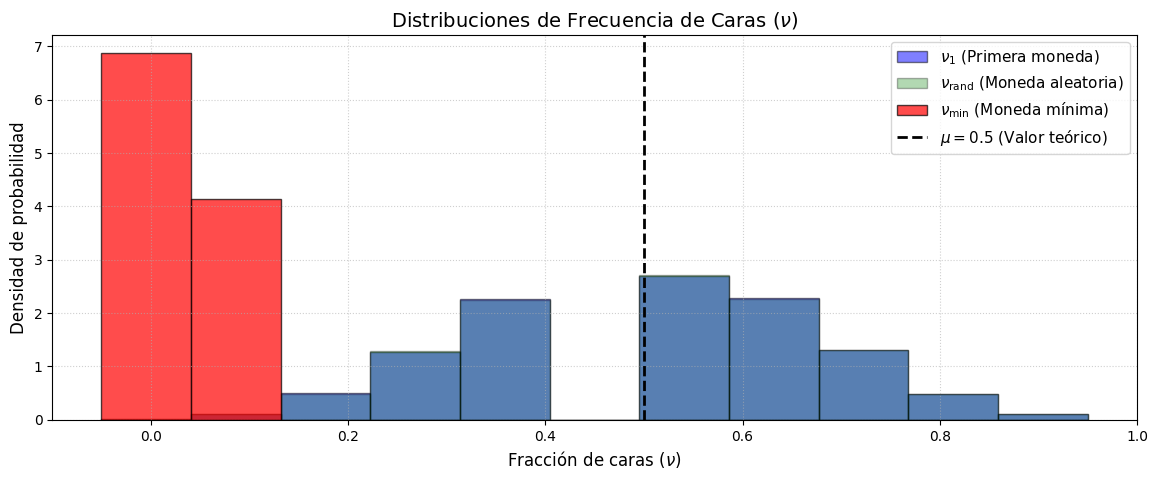

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Inicializar variables
num_ejecuciones = 100000
num_monedas = 1000
N = 10
mu = 0.5

# np.random.binomial da el conteo de caras para cada moneda
frecuencias = np.random.binomial(n=N, p=mu, size=(num_ejecuciones, num_monedas)) / N

# Separar cada variable
nu_1 = frecuencias[:, 0]  # Primera moneda
nu_rand = frecuencias[np.arange(num_ejecuciones), np.random.randint(0, num_monedas, size=num_ejecuciones)]  # Moneda aleatoria
nu_min = np.min(frecuencias, axis=1)  # Moneda con el mínimo de caras

# Graficación de los histogramas
plt.figure(figsize=(14, 5))

bins = np.linspace(0, 1, 12) - 0.05

plt.hist(nu_1, bins=bins, alpha=0.5, density=True, label=r'$\nu_1$ (Primera moneda)', color='blue', edgecolor='black')
plt.hist(nu_rand, bins=bins, alpha=0.3, density=True, label=r'$\nu_{\mathrm{rand}}$ (Moneda aleatoria)', color='green', edgecolor='black')
plt.hist(nu_min, bins=bins, alpha=0.7, density=True, label=r'$\nu_{\mathrm{min}}$ (Moneda mínima)', color='red', edgecolor='black')

plt.title('Distribuciones de Frecuencia de Caras ' + r'($\nu$)', fontsize=14)
plt.xlabel(r'Fracción de caras ($\nu$)', fontsize=12)
plt.ylabel('Densidad de probabilidad', fontsize=12)
plt.axvline(x=mu, color='black', linestyle='--', linewidth=2, label=r'$\mu = 0.5$ (Valor teórico)')
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

(c) Utilizando (b), grafique las estimaciones de $P[\vert{}\nu - \mu\vert{} > \epsilon]$ en función de $\epsilon$, junto con la cota de Hoeffding $2e^{-2N\epsilon^2}$ (en el mismo gráfico)

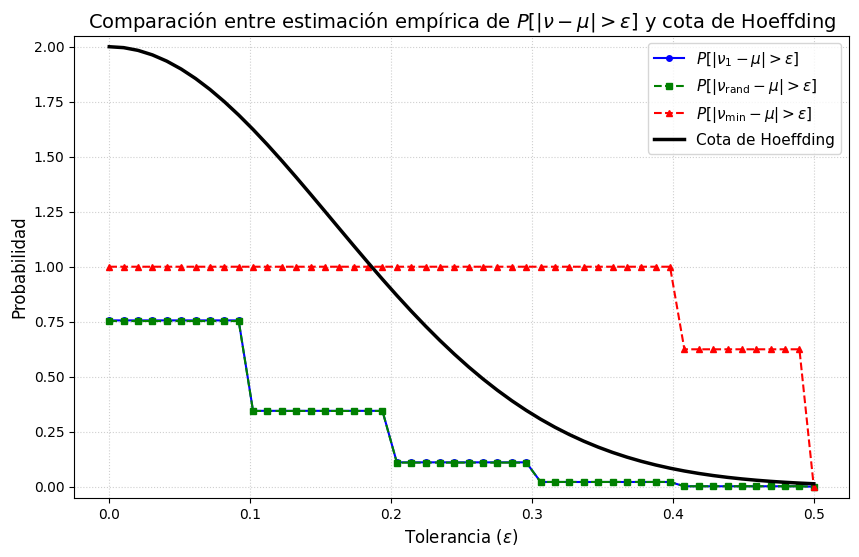

In [4]:
# Valores de epsilon entre 0 y 0.5
epsilon_valores = np.linspace(0.0, 0.5, 50)

# Probabilidades empíricas
prob_nu_1 = [np.mean(np.abs(nu_1 - mu) > eps) for eps in epsilon_valores]
prob_nu_rand = [np.mean(np.abs(nu_rand - mu) > eps) for eps in epsilon_valores]
prob_nu_min = [np.mean(np.abs(nu_min - mu) > eps) for eps in epsilon_valores]

cota_hoeffding = 2 * np.exp(-2 * N * (epsilon_valores ** 2))

# Graficación
plt.figure(figsize=(10, 6))

plt.plot(epsilon_valores, prob_nu_1, 'o-', label=r'$P[|\nu_1 - \mu| > \epsilon]$', color='blue', markersize=4)
plt.plot(epsilon_valores, prob_nu_rand, 's--', label=r'$P[|\nu_{\mathrm{rand}} - \mu| > \epsilon]$', color='green', markersize=4)
plt.plot(epsilon_valores, prob_nu_min, '^--', label=r'$P[|\nu_{\mathrm{min}} - \mu| > \epsilon]$', color='red', markersize=4)
plt.plot(epsilon_valores, cota_hoeffding, 'k-', linewidth=2.5, label=r'Cota de Hoeffding')

plt.title(r'Comparación entre estimación empírica de $P[|\nu - \mu| > \epsilon]$ y cota de Hoeffding', fontsize=14)
plt.xlabel(r'Tolerancia ($\epsilon$)', fontsize=12)
plt.ylabel('Probabilidad', fontsize=12)
plt.ylim(-0.05, 2.05)  # La cota de Hoeffding teórica puede ser > 1 para epsilon pequeños
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

plt.show()

(d) ¿Qué monedas cumplen la cota de Hoeffding y cuáles no? Explique por qué



*   $c_1$ y $c_{\text{rand}}$ si cumplen la cota
*   $c_{\text{min}}$ no cumple la cota

La desigualdad de Hoeffding dice que la hipótesis, en este caso la moneda, sea seleccionada antes de ver los datos, o de forma completamente independiente al resultado de los experimentos. Tanto $c_1$ como $c_{\text{rand}}$ se definen sin mirar el resultado de sus lanzamientos. Por lo tanto, para ellas se cumple la desigualdad.

En cambio, para seleccionar $c_{\text{min}}$, primero se realizan todos los lanzamientos y luego se busca la moneda que minimizó $\nu$. Esto hace que no se cumpla la hipótesis de independencia. Al elegir la mejor o peor opción entre 1000 posibilidades, se está forzando un sesgo de selección, haciendo que la probabilidad real de error sea mayor que la cota de Hoeffding individual.

(e) Relacione la parte (d) con los múltiples intervalos/contenedores de la figura


*   Una sola hipótesis corresponde a $c_1$ o $c_{\text{rand}}$. Cuando se evalua una única hipótesis fija sobre una muestra de datos de tamaño N, la frecuencia observada en la muestra es un buen estimador del error real fuera de la muestra. Por tanto, la cota de Hoeffding garantiza generalización de forma individual.
*   Para multiples contenedores, o un espacio de hipótesis $\mathcal{H}$ con $M$ elementos. Lanzar M = 1000 monedas equivale a evaluar M hipótesis distintas $h_1, h_2, \dots, h_M$ sobre el mismo conjunto de datos. Elegir $c_{\text{min}}$ es igual al proceso de aprendizaje en el cual el algoritmo busca el modelo que minimiza el error de entrenamiento.

